# 09 — 提出: ExtraTrees + 樹種間一貫性波数選択

**CV結果 (GroupKFold, 元スケールRMSE):**
- 現行ベスト: 全波数 RF(SNV+SG1)  = **20.19%**
- 本モデル:   ExtraTrees + 符号一致選択(sign>=0.8, r_std<=0.05) = **17.03%**

**最終モデルの方針:**
- 波数選択の基準を全訓練13種で計算（fold-internal CVと同じ閾値）
- 選択した波数で全訓練データを使いExtraTreesを学習
- テストデータに同じ前処理・波数選択を適用して予測

In [1]:
import sys
sys.path.insert(0, '..')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.ensemble import ExtraTreesRegressor
from sklearn.model_selection import GroupKFold

from src.utils import load_data, parse_spectra, get_groups, rmse, make_submission, setup_japanese_font
from src.preprocessing import snv, savitzky_golay

plt.rcParams['figure.dpi'] = 110
setup_japanese_font()

train_df, test_df = load_data()
train_meta, y_train, X_train_raw, wn = parse_spectra(train_df)
test_meta,  _,       X_test_raw,  _  = parse_spectra(test_df)

groups = get_groups(train_meta)
y_train = y_train.values.astype(float)

print('train:', X_train_raw.shape, '  y:', y_train.min(), '-', y_train.max())
print('test: ', X_test_raw.shape)
print('train species:', np.unique(groups).tolist())
print('test  species:', train_df['species number'].unique().tolist()[:0] or
      test_df['species number'].unique().tolist())

train: (1322, 1555)   y: 0.840336134 - 298.5815603
test:  (550, 1555)
train species: [1, 3, 4, 5, 8, 11, 12, 13, 14, 15, 16, 17, 19]
test  species: [2, 6, 7, 9, 10, 18]


## 1. 前処理・波数選択の定義

In [2]:
# SNV+SG1 前処理
def preproc(X):
    return savitzky_golay(snv(X), window_length=11, polyorder=2, deriv=1)

# 波数ごとの Pearson r ベクトル
def corr_vec(X, yv):
    yc = yv - yv.mean(); Xc = X - X.mean(axis=0)
    num = (Xc * yc[:, None]).sum(0)
    den = np.sqrt((Xc**2).sum(0) * (yc**2).sum())
    with np.errstate(invalid='ignore', divide='ignore'):
        return np.where(den > 0, num / den, 0.0)

# 全訓練13種で符号一致率・r_std を計算し波数を選択
def select_wavenumbers(X_pp, y, g, sign_thresh=0.8, std_thresh=0.05):
    """全訓練データを使って波数選択マスクを返す。"""
    r_list = [corr_vec(X_pp[g == sp], y[g == sp])
              for sp in sorted(set(g)) if (g == sp).sum() >= 3]
    r_mat     = np.array(r_list)
    sign_cons = np.abs(np.sign(r_mat).sum(0)) / len(r_list)
    r_std_arr = r_mat.std(0)
    return (sign_cons >= sign_thresh) & (r_std_arr <= std_thresh)

SIGN_THRESH = 0.8
STD_THRESH  = 0.05
ET_KW = dict(n_estimators=300, max_features=0.3, random_state=42, n_jobs=-1)

print('前処理・定義完了')

前処理・定義完了


## 2. CV検証（GroupKFold 5-fold, 元スケールRMSE）

提出前に実験08と同じCVスコアが再現できることを確認する。  
**注意:** 各foldの訓練側のみで波数選択を計算（リーク防止）

In [3]:
SPLITS = list(GroupKFold(n_splits=5).split(X_train_raw, y_train, groups))
fold_sp = [sorted(set(groups[va])) for _, va in SPLITS]
print('Fold validation species:')
for i, sps in enumerate(fold_sp):
    print(f'  Fold{i+1}: {sps}')

fold_rmses = []
for fold_i, (tr, va) in enumerate(SPLITS):
    Xtr_pp = preproc(X_train_raw[tr])
    Xva_pp = preproc(X_train_raw[va])
    ytr, yva = y_train[tr], y_train[va]

    # 波数選択: 訓練側のみで計算
    sel = select_wavenumbers(Xtr_pp, ytr, groups[tr], SIGN_THRESH, STD_THRESH)

    et = ExtraTreesRegressor(**ET_KW)
    et.fit(Xtr_pp[:, sel], ytr)
    pred = et.predict(Xva_pp[:, sel])
    fold_rmses.append(rmse(yva, pred))
    print(f'  Fold{fold_i+1} (sp{fold_sp[fold_i]}): {fold_rmses[-1]:.2f}%  n_wn={sel.sum()}')

print(f'\nCV RMSE = {np.mean(fold_rmses):.2f}% +/- {np.std(fold_rmses):.2f}%')
print(f'(実験08での結果: 17.03% +/- 10.46%)')

Fold validation species:
  Fold1: [np.int64(11), np.int64(12)]
  Fold2: [np.int64(5), np.int64(14)]
  Fold3: [np.int64(15), np.int64(17), np.int64(19)]
  Fold4: [np.int64(1), np.int64(3), np.int64(4)]
  Fold5: [np.int64(8), np.int64(13), np.int64(16)]


  Fold1 (sp[np.int64(11), np.int64(12)]): 16.21%  n_wn=365


  Fold2 (sp[np.int64(5), np.int64(14)]): 11.75%  n_wn=378


  Fold3 (sp[np.int64(15), np.int64(17), np.int64(19)]): 37.42%  n_wn=530


  Fold4 (sp[np.int64(1), np.int64(3), np.int64(4)]): 10.21%  n_wn=401


  Fold5 (sp[np.int64(8), np.int64(13), np.int64(16)]): 9.54%  n_wn=352

CV RMSE = 17.03% +/- 10.46%
(実験08での結果: 17.03% +/- 10.46%)


## 3. 最終モデルの学習

波数選択を**全13種**で計算し、全訓練データでExtraTreesを学習する。

In [4]:
# 全訓練データに前処理
X_train_pp = preproc(X_train_raw)
X_test_pp  = preproc(X_test_raw)

# 波数選択 (全13種で計算)
sel_final = select_wavenumbers(X_train_pp, y_train, groups, SIGN_THRESH, STD_THRESH)
n_sel = int(sel_final.sum())
print(f'選択波数: {n_sel} / {len(wn)}')
print(f'  4760 cm^-1: {sel_final[np.argmin(np.abs(wn - 4760))]}')
print(f'  5200 cm^-1: {sel_final[np.argmin(np.abs(wn - 5200))]}')
print(f'  6900 cm^-1: {sel_final[np.argmin(np.abs(wn - 6900))]}')

# 学習
print(f'\nExtraTrees 学習中 (n_feat={n_sel})...')
et_final = ExtraTreesRegressor(**ET_KW)
et_final.fit(X_train_pp[:, sel_final], y_train)

# in-sample RMSE (sanity check)
pred_tr = et_final.predict(X_train_pp[:, sel_final])
print(f'訓練RMSE (in-sample): {rmse(y_train, pred_tr):.2f}%  (過学習確認用)')

選択波数: 374 / 1555
  4760 cm^-1: True
  5200 cm^-1: False
  6900 cm^-1: False

ExtraTrees 学習中 (n_feat=374)...


訓練RMSE (in-sample): 0.00%  (過学習確認用)


## 4. 選択波数の確認

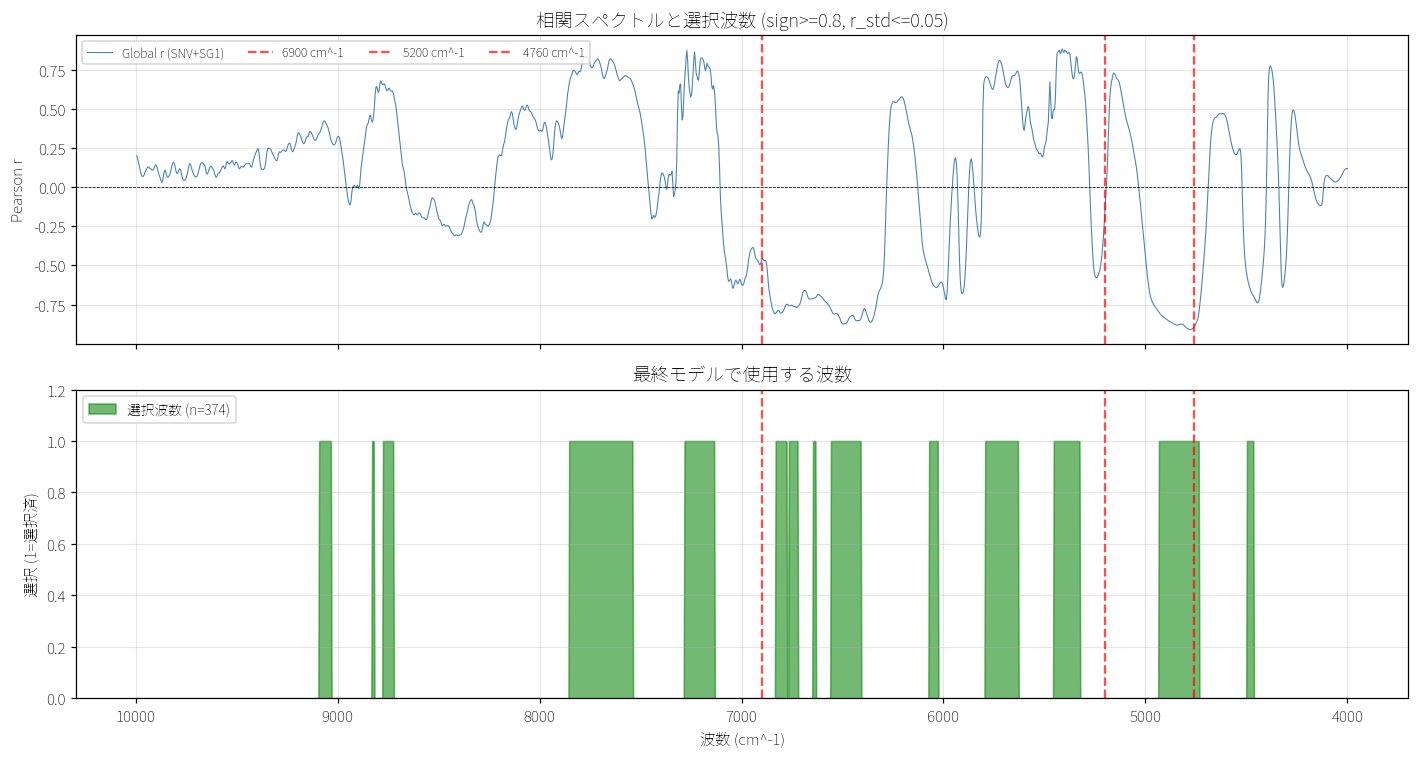

In [5]:
r_global = corr_vec(X_train_pp, y_train)

fig, axes = plt.subplots(2, 1, figsize=(13, 7), sharex=True)

axes[0].plot(wn, r_global, 'steelblue', lw=0.7, label='Global r (SNV+SG1)')
axes[0].axhline(0, color='k', lw=0.5, ls='--')
axes[0].set_ylabel('Pearson r')
axes[0].set_title(f'相関スペクトルと選択波数 (sign>={SIGN_THRESH}, r_std<={STD_THRESH})')
for bname, bwn in [('6900', 6900), ('5200', 5200), ('4760', 4760)]:
    axes[0].axvline(bwn, color='red', lw=1.5, ls='--', alpha=0.7, label=f'{bname} cm^-1')
axes[0].legend(loc='upper left', fontsize=8, ncol=4)
axes[0].grid(True, alpha=0.3)

axes[1].fill_between(wn, sel_final.astype(float), alpha=0.55, color='green', label=f'選択波数 (n={n_sel})')
axes[1].set_ylim(0, 1.2)
axes[1].set_ylabel('選択 (1=選択済)')
axes[1].set_title('最終モデルで使用する波数')
for bname, bwn in [('6900', 6900), ('5200', 5200), ('4760', 4760)]:
    axes[1].axvline(bwn, color='red', lw=1.5, ls='--', alpha=0.7)
axes[1].legend(loc='upper left', fontsize=9)
axes[1].grid(True, alpha=0.3)

axes[1].set_xlabel('波数 (cm^-1)')
axes[1].invert_xaxis()
plt.tight_layout()
plt.show()

## 5. テスト予測 & 提出ファイル生成

In [6]:
test_pred = et_final.predict(X_test_pp[:, sel_final])
print(f'テスト予測: min={test_pred.min():.2f}  max={test_pred.max():.2f}  mean={test_pred.mean():.2f}')
print(f'負の予測値: {(test_pred < 0).sum()} 件')

# 含水率は 0 未満にならない
test_pred = np.clip(test_pred, 0, None)

sub = make_submission(test_meta, test_pred,
                      path='../submissions/extratrees_sign08_std005.csv')
sub.head(10)

テスト予測: min=10.86  max=170.77  mean=44.49
負の予測値: 0 件
Saved submission: ../submissions/extratrees_sign08_std005.csv


,sample_number,moisture
0,95,170.773672
1,96,155.587676
2,97,149.095151
3,98,141.169901
4,99,140.580263
5,100,137.411593
6,101,133.198996
7,102,131.080117
8,103,128.520084
9,104,127.462273


## 6. 予測分布の確認

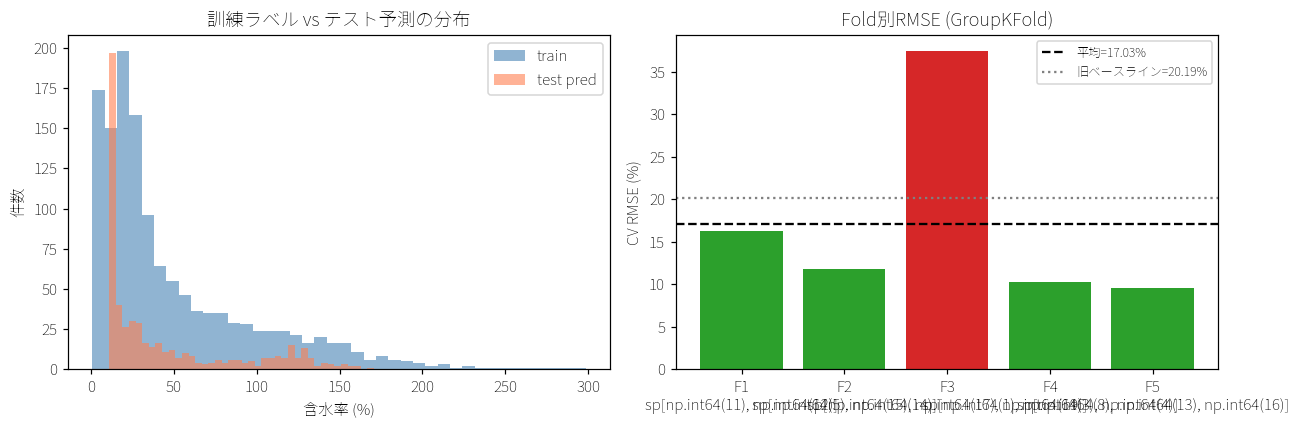

提出ファイル: submissions/extratrees_sign08_std005.csv


In [7]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].hist(y_train, bins=40, alpha=0.6, color='steelblue', label='train')
axes[0].hist(test_pred, bins=40, alpha=0.6, color='coral', label='test pred')
axes[0].set_xlabel('含水率 (%)')
axes[0].set_ylabel('件数')
axes[0].set_title('訓練ラベル vs テスト予測の分布')
axes[0].legend()

# CV fold別RMSE bar
fold_labels = [f'F{i+1}\nsp{fold_sp[i]}' for i in range(5)]
colors = ['#d62728' if r > 30 else '#2ca02c' for r in fold_rmses]
axes[1].bar(fold_labels, fold_rmses, color=colors)
axes[1].axhline(np.mean(fold_rmses), color='black', ls='--',
                label=f'平均={np.mean(fold_rmses):.2f}%')
axes[1].axhline(20.19, color='gray', ls=':', label='旧ベースライン=20.19%')
axes[1].set_ylabel('CV RMSE (%)')
axes[1].set_title('Fold別RMSE (GroupKFold)')
axes[1].legend(fontsize=8)

plt.tight_layout()
plt.show()

print('提出ファイル: submissions/extratrees_sign08_std005.csv')